# Build ML model for analysis and prediction of DNA-encoded library data.

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path
from rdkit import RDLogger
from tqdm.notebook import tqdm

# Get the main logger
logger = RDLogger.logger()

# Set its level to ERROR so only serious messages show up
logger.setLevel(RDLogger.ERROR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#verify Cuda is actually working

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda


## Setup.

In [2]:
readout = 'kindel_del'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
import s3fs

for dataset in ['ddr1', 'mapk14']: 
    fs = s3fs.S3FileSystem(anon=True)
    info = fs.info(f'kin-del-2024/data/{dataset}.parquet')
    print(f"File size for {dataset}: {info['size']/1e6:.2f} MB")

File size for ddr1: 6782.18 MB
File size for mapk14: 6911.55 MB


In [5]:
import pyarrow.parquet as pq

def read_first_n_rows(file_path, n_rows):
    parquet_file = pq.ParquetFile(file_path)
    
    num_row_groups = parquet_file.num_row_groups
    
    rows_read = 0
    result = []

    for i in range(num_row_groups):
        row_group = parquet_file.read_row_group(i)
        df = row_group.to_pandas()

        if rows_read + len(df) >= n_rows:
            result.append(df.head(n_rows - rows_read))
            break
        
        result.append(df)
        rows_read += len(df)

    final_df = pd.concat(result, ignore_index=True).head(n_rows)
    return final_df

In [6]:
def count_rows(file_path):
    parquet_file = pq.ParquetFile(file_path)
    total_rows = sum(parquet_file.metadata.row_group(i).num_rows
                     for i in range(parquet_file.num_row_groups))
    return total_rows

In [7]:
target = f"{DATA}/ddr1.parquet"

row_count = count_rows(target)
print(f"Total rows: {row_count}")

N = 1000  # Number of rows to load - for prototyping
df = read_first_n_rows(target, N)

Total rows: 67641617


## Preprocessing

In [8]:
import numpy as np
import pandas as pd

# Average triplicates
df['target_mean'] = df[['seq_target_1','seq_target_2','seq_target_3']].mean(axis=1)
df['control_mean'] = df[['seq_matrix_1','seq_matrix_2','seq_matrix_3']].mean(axis=1)

# Add a pseudocount to avoid division by zero
pseudocount = 1

# Compute log2 enrichment
df['log_enrichment'] = np.log2((df['target_mean'] + pseudocount) / (df['control_mean'] + pseudocount))

# Optional: normalize by library loading
df['log_enrichment_norm'] = np.log2((df['target_mean'] + pseudocount) / (df['seq_load'] + pseudocount))


In [9]:
# Define a function to compute Morgan fingerprints (a type of molecular fingerprint)
def compute_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))
    else:
        return None

# Compute the fingerprints for each synthon and the final molecule
def get_fingerprints(df):
    df['fp_a'] = df['smiles_a'].apply(compute_fingerprint)
    df['fp_b'] = df['smiles_b'].apply(compute_fingerprint)
    df['fp_c'] = df['smiles_c'].apply(compute_fingerprint)
    df['fp_final'] = df['smiles'].apply(compute_fingerprint)
    
    # Drop rows where any fingerprint is missing
    df = df.dropna(subset=['fp_a', 'fp_b', 'fp_c', 'fp_final']).reset_index(drop=True)
    return df

# Apply to your DataFrame
df = get_fingerprints(df)

# Convert fingerprints to numpy arrays (bit vectors)
fingerprints = np.array([
    np.concatenate([row['fp_a'], row['fp_b'], row['fp_c'], row['fp_final']])
    for _, row in df.iterrows()
])
    
fingerprints = np.array(fingerprints)

[05:27:19] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,
[05:27:19] SMILES Parse Error: Failed parsing SMILES 'CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,' for input: 'CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,'
[05:27:19] SMILES Parse Error: syntax error while parsing: [H][C@@](CCC(O)=O)(NC(=O)OC(C)(C)C)C(=O)OC,
[05:27:19] SMILES Parse Error: Failed parsing SMILES '[H][C@@](CCC(O)=O)(NC(=O)OC(C)(C)C)C(=O)OC,' for input: '[H][C@@](CCC(O)=O)(NC(=O)OC(C)(C)C)C(=O)OC,'
[05:27:19] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,
[05:27:19] SMILES Parse Error: Failed parsing SMILES 'CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,' for input: 'CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,'
[05:27:19] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc

In [10]:
# Remove molecules with failed SMILES
df = df[df['fp_final'].notnull()]

# Filter molecules with very low pre-population
min_load = 10
df = df[df['seq_load'] >= min_load]


In [11]:
df['fp_final_arr'] = df['smiles'].apply(compute_fingerprint)

# Stack fingerprints as features
X = np.stack(df['fp_final_arr'].values)
y = df['log_enrichment'].values

## GNN model - multiple synthons

In [12]:
def mol_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # ---- Atom features ----
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            int(atom.GetIsAromatic()),
            atom.GetFormalCharge()
        ])
    x = torch.tensor(atom_features, dtype=torch.float)

    # ---- Edge features ----
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        # Only add one direction
        edge_index.append([i, j])
        edge_attr.append([bond.GetBondTypeAsDouble()])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    data.smiles = smiles  # for visualization

    return data


In [13]:
from torch_geometric.data import InMemoryDataset

class MultiSynthonDELDataset(InMemoryDataset):
    def __init__(self, df, transform=None):
        super().__init__('.', transform)
        self.data_list = []
        
        for idx, row in df.iterrows():
            graphs = []
            for col in ['smiles_a', 'smiles_b', 'smiles_c']:
                g = mol_to_graph(row[col])
                if g is None:
                    break
                graphs.append(g)
            else:  # Only keep compounds where all synthons parsed correctly
                data = {
                    'synthon_graphs': graphs,
                    'final_smiles': row['smiles'],  # <--- add this
                    'y': torch.tensor([row['log_enrichment']], dtype=torch.float)
                }
                self.data_list.append(data)
    
    def len(self):
        return len(self.data_list)
    
    def get(self, idx):
        return self.data_list[idx]



In [14]:
# ---- Custom collate function for multi-synthon graphs ----
def multi_synthon_collate(batch, device='cpu'):
    """
    Collates a batch of dicts {'synthon_graphs': [...], 'y': tensor} into:
    - batched graphs for each synthon
    - target tensor
    Moves all tensors to the given device.
    """
    synthon_graphs_list = list(zip(*[item['synthon_graphs'] for item in batch]))
    ys = torch.stack([item['y'] for item in batch]).view(-1).to(device)

    batched_graphs = []
    for graphs in synthon_graphs_list:
        # Move each Data object to device before batching
        graphs = [g.to(device) for g in graphs]
        batched_graphs.append(Batch.from_data_list(graphs))

    return batched_graphs, ys


In [15]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# Initialize the dataset
dataset = MultiSynthonDELDataset(df)

# Compute sizes
total_len = len(dataset)
train_size = int(0.7 * total_len)
val_size = int(0.1 * total_len)
test_size = total_len - train_size - val_size

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducibility
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True,
    collate_fn=lambda batch: multi_synthon_collate(batch, device=device)
)
val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False,
    collate_fn=lambda batch: multi_synthon_collate(batch, device=device)
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False,
    collate_fn=lambda batch: multi_synthon_collate(batch, device=device)
)


print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 495, Val: 70, Test: 143


#### Model spec

In [16]:
from torch_geometric.nn import GATConv, global_add_pool
import torch
import torch.nn as nn

class MultiSynthonGAT(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, num_synthons=3, heads=1):
        super().__init__()
        self.num_synthons = num_synthons
        self.heads = heads
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # GAT encoder per synthon
        for _ in range(num_synthons):
            conv_layers = nn.ModuleList()
            bn_layers = nn.ModuleList()
            for i in range(num_layers):
                in_dim = hidden_dim if i > 0 else 4
                out_dim = hidden_dim // heads
                conv_layers.append(GATConv(in_dim, out_dim, heads=heads, concat=True))
                bn_layers.append(nn.BatchNorm1d(hidden_dim))
            self.convs.append(conv_layers)
            self.bns.append(bn_layers)

        self.fc = nn.Linear(hidden_dim * num_synthons, 1)

    def forward(self, data_list, return_attention=False):
        embeddings = []
        all_attentions = []  # list over molecules

        for syn_idx, g in enumerate(data_list):
            x, edge_index, batch = g.x, g.edge_index, g.batch

            synthon_layer_attn = []   # will contain one entry per GAT layer

            for conv, bn in zip(self.convs[syn_idx], self.bns[syn_idx]):

                if return_attention:
                    x, attn = conv(x, edge_index, return_attention_weights=True)

                    # PyG gives: attn = (edge_idx, alpha) with shape [num_edges, heads]
                    edge_idx, alpha = attn

                    # average across heads if needed
                    if alpha.ndim == 2:
                        alpha = alpha.mean(dim=1)

                    # store exactly ONE tuple per layer
                    synthon_layer_attn.append((edge_idx, alpha))

                else:
                    x = conv(x, edge_index)

                x = bn(x)
                x = torch.relu(x)

            # pooling
            pooled = global_add_pool(x, batch)
            embeddings.append(pooled)

            if return_attention:
                # now split attention per molecule
                batch_size = pooled.size(0)
                mol_attn = []

                for b_idx in range(batch_size):
                    per_layer = []
                    for edge_idx, alpha in synthon_layer_attn:
                        mask = (batch[edge_idx[0]] == b_idx)
                        per_layer.append((edge_idx[:, mask], alpha[mask]))
                    mol_attn.append(per_layer)

                all_attentions.append(mol_attn)

        out = torch.cat(embeddings, dim=1)

        if return_attention:
            # collapse synthon dimension into molecule dimension
            merged = []
            # all_attentions = [syn0_list, syn1_list, syn2_list]
            # each syn_list has len=batch_size entries
            batch_size = len(all_attentions[0])
            for b in range(batch_size):
                merged.append([
                    all_attentions[s][b] for s in range(self.num_synthons)
                ])
            return self.fc(out), merged

        return self.fc(out)


In [17]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- Model, optimizer, loss ----
model = MultiSynthonGAT(hidden_dim=64, num_layers=3, num_synthons=3, heads=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ---- Training loop ----
num_epochs = 20

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    total_loss = 0
    for synthon_graphs, y in train_loader:
        synthon_graphs = [g.to(device) for g in synthon_graphs]
        y = y.to(device)
        
        optimizer.zero_grad()
        y_pred = model(synthon_graphs)
        loss = criterion(y_pred.view(-1), y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
    
    avg_train_loss = total_loss / len(train_loader.dataset)
    
    # ---- Validation ----
    model.eval()
    y_true_list = []
    y_pred_list = []
    
    with torch.no_grad():
        for synthon_graphs, y in val_loader:
            synthon_graphs = [g.to(device) for g in synthon_graphs]
            y = y.to(device)
            y_pred = model(synthon_graphs)
            
            y_true_list.append(y.cpu())
            y_pred_list.append(y_pred.cpu())
    
    y_true = torch.cat(y_true_list).numpy()
    y_pred = torch.cat(y_pred_list).numpy()
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss={avg_train_loss:.4f} | Val R²={r2:.3f} | Val RMSE={rmse:.3f}")


Epoch 1/20 | Train Loss=3.3112 | Val R²=-0.965 | Val RMSE=1.591
Epoch 2/20 | Train Loss=2.3175 | Val R²=-0.626 | Val RMSE=1.447
Epoch 3/20 | Train Loss=1.8719 | Val R²=-0.458 | Val RMSE=1.371
Epoch 4/20 | Train Loss=1.3045 | Val R²=0.042 | Val RMSE=1.111
Epoch 5/20 | Train Loss=1.0053 | Val R²=0.029 | Val RMSE=1.118
Epoch 6/20 | Train Loss=0.8831 | Val R²=0.059 | Val RMSE=1.101
Epoch 7/20 | Train Loss=0.9519 | Val R²=-0.168 | Val RMSE=1.227
Epoch 8/20 | Train Loss=1.0503 | Val R²=0.261 | Val RMSE=0.976
Epoch 9/20 | Train Loss=0.8437 | Val R²=0.257 | Val RMSE=0.979
Epoch 10/20 | Train Loss=0.8972 | Val R²=0.259 | Val RMSE=0.977
Epoch 11/20 | Train Loss=0.8201 | Val R²=0.234 | Val RMSE=0.993
Epoch 12/20 | Train Loss=0.7554 | Val R²=0.405 | Val RMSE=0.876
Epoch 13/20 | Train Loss=0.7822 | Val R²=0.225 | Val RMSE=0.999
Epoch 14/20 | Train Loss=1.0372 | Val R²=0.020 | Val RMSE=1.124
Epoch 15/20 | Train Loss=0.8556 | Val R²=0.441 | Val RMSE=0.848
Epoch 16/20 | Train Loss=0.7232 | Val R²=0.12

### Save the model.

In [18]:
torch.save(model.state_dict(), "best_multisynthon_gnn.pth")

To reload it later, need to feed in the best saved hyperparameters.

In [19]:
# Recreate the model with the same hyperparameters
# Best hyperparameters: hidden_dim=64, num_layers=3, lr=0.0005
model = MultiSynthonGAT(hidden_dim=64, num_layers=3, num_synthons=3, heads=4)
model.load_state_dict(torch.load("best_multisynthon_gnn.pth"))
model.to(device)
model.eval()  # important for inference

MultiSynthonGAT(
  (convs): ModuleList(
    (0-2): 3 x ModuleList(
      (0): GATConv(4, 16, heads=4)
      (1-2): 2 x GATConv(64, 16, heads=4)
    )
  )
  (bns): ModuleList(
    (0-2): 3 x ModuleList(
      (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc): Linear(in_features=192, out_features=1, bias=True)
)

## Viz of attention weights.

In [20]:
from math import ceil
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap
from io import BytesIO
from PIL import Image
import numpy as np
import torch

def visualize_top_attention(attention_list, dataset, syn_idx=0, top_n=5, layer_idx=-1, ncols=5):
    """
    Visualize top-N molecules by maximum attention for a given synthon and GAT layer.

    Parameters
    ----------
    attention_list : list
        Flat list of per-molecule attention: attention_list[mol_idx][syn_idx][layer_idx]
    dataset : MultiSynthonDELDataset
        Dataset object containing synthon graphs
    syn_idx : int
        Which synthon to visualize (0,1,2)
    top_n : int
        Number of molecules to display
    layer_idx : int
        Which GAT layer (-1 for last)
    ncols : int
        Number of columns per row
    """
    # ---- Step 1: Compute max attention per molecule ----
    max_attn_per_mol = []
    for i, mol_att in enumerate(attention_list):
        # pick the layer
        layer_attn = mol_att[syn_idx][-1] if layer_idx==-1 else mol_att[syn_idx][layer_idx]

        # move to CPU and average heads
        layer_attn = layer_attn.detach().cpu()
        if layer_attn.ndim == 2:
            layer_attn = layer_attn.mean(dim=1)

        max_val = layer_attn.max().item()
        max_attn_per_mol.append((i, max_val))

    # ---- Step 2: Select top-N molecules ----
    max_attn_per_mol.sort(key=lambda x: x[1], reverse=True)
    top_indices = [idx for idx, _ in max_attn_per_mol[:top_n]]

    # ---- Step 3: Set up plotting ----
    nrows = ceil(top_n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = axes.flatten()  # flatten in case of multiple rows
    cmap = get_cmap("Reds")

    for ax_idx, mol_idx in enumerate(top_indices):
        ax = axes[ax_idx]
        data = dataset.data_list[mol_idx]['synthon_graphs'][syn_idx]
        smiles = data.smiles
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue

        edge_index = data.edge_index
        edge_pairs = edge_index.t().tolist()

        # get attention for the correct layer
        alpha = attention_list[mol_idx][syn_idx][-1] if layer_idx==-1 else attention_list[mol_idx][syn_idx][layer_idx]
        alpha = alpha.detach().cpu()
        if alpha.ndim == 2:
            alpha = alpha.mean(dim=1)

        # ---- Aggregate attention per bond ----
        bond_attn = {}
        for idx, (i, j) in enumerate(edge_pairs):
            bond = mol.GetBondBetweenAtoms(i, j)
            if bond is not None:
                if bond.GetIdx() not in bond_attn:
                    bond_attn[bond.GetIdx()] = []
                bond_attn[bond.GetIdx()].append(alpha[idx].item())

        # average multiple contributions per bond
        bond_attn = {k: np.mean(v) for k, v in bond_attn.items()}

        # ---- Normalize bond attention ----
        if len(bond_attn) > 0:
            min_val, max_val = min(bond_attn.values()), max(bond_attn.values())
            bond_colors = {k: (v - min_val)/(max_val - min_val + 1e-8) for k,v in bond_attn.items()}
        else:
            bond_colors = {}

        # ---- Atom colors from connected bond attention ----
        atom_colors = {i:0.0 for i in range(mol.GetNumAtoms())}
        for bond_idx, weight in bond_colors.items():
            bond = mol.GetBondWithIdx(bond_idx)
            atom_colors[bond.GetBeginAtomIdx()] += weight
            atom_colors[bond.GetEndAtomIdx()] += weight
        if len(atom_colors) > 0:
            max_val = max(atom_colors.values())
            if max_val > 0:
                atom_colors = {k: v/max_val for k,v in atom_colors.items()}

        # ---- Draw molecule ----
        Draw.rdMolDraw2D.PrepareMolForDrawing(mol)
        drawer = Draw.MolDraw2DCairo(300, 300)
        drawer.DrawMolecule(
            mol,
            highlightAtoms=list(atom_colors.keys()),
            highlightBonds=list(bond_colors.keys()),
            highlightBondColors={k:cmap(v)[:3] for k,v in bond_colors.items()},
            highlightAtomColors={k:cmap(v)[:3] for k,v in atom_colors.items()}
        )
        drawer.FinishDrawing()
        img_bytes = drawer.GetDrawingText()
        img = Image.open(BytesIO(img_bytes))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Mol {mol_idx}\nMax attn={max_attn_per_mol[mol_idx][1]:.3f}")

    # hide unused axes
    for ax_idx in range(len(top_indices), len(axes)):
        axes[ax_idx].axis('off')

    # ---- Colorbar ----
    sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    fig.subplots_adjust(bottom=0.15, hspace=0.3)
    fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.01, label="Normalized attention")
    plt.show()


In [21]:
model.eval()

attention_list = []  # <--- initialize BEFORE the loop

with torch.no_grad():
    for i, (synthon_graphs, y) in enumerate(val_loader):
        if i > 1:  # only a few batches
            break
        synthon_graphs = [g.to(device) for g in synthon_graphs]
        _, attentions = model(synthon_graphs, return_attention=True)
        attention_list.extend(attentions)

# Flatten batch-level attention into per-molecule attention
flat_attention_list = []
for batch_att in attention_list:
    flat_attention_list.extend(batch_att)

print(type(flat_attention_list[0]))
print(len(flat_attention_list[0]))
print(type(flat_attention_list[0][0]))
print(flat_attention_list[0][0])


<class 'list'>
3
<class 'tuple'>
(tensor([[ 0,  1,  2,  2,  4,  5,  4,  7,  8,  8, 10, 11,  0,  1,  2,  3,  4,  5,
          6,  7,  8,  9, 10, 11, 12],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  0,  1,  2,  3,  4,  5,
          6,  7,  8,  9, 10, 11, 12]], device='cuda:0'), tensor([0.5018, 0.5360, 0.4300, 0.5000, 0.4810, 0.4640, 0.4640, 0.5360, 0.4300,
        0.4810, 0.4660, 0.5151, 1.0000, 0.4982, 0.4640, 0.5700, 0.5000, 0.5190,
        0.5360, 0.5360, 0.4640, 0.5700, 0.5190, 0.5340, 0.4849],
       device='cuda:0'))


/tmp/ipykernel_7294/1861860072.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Reds")


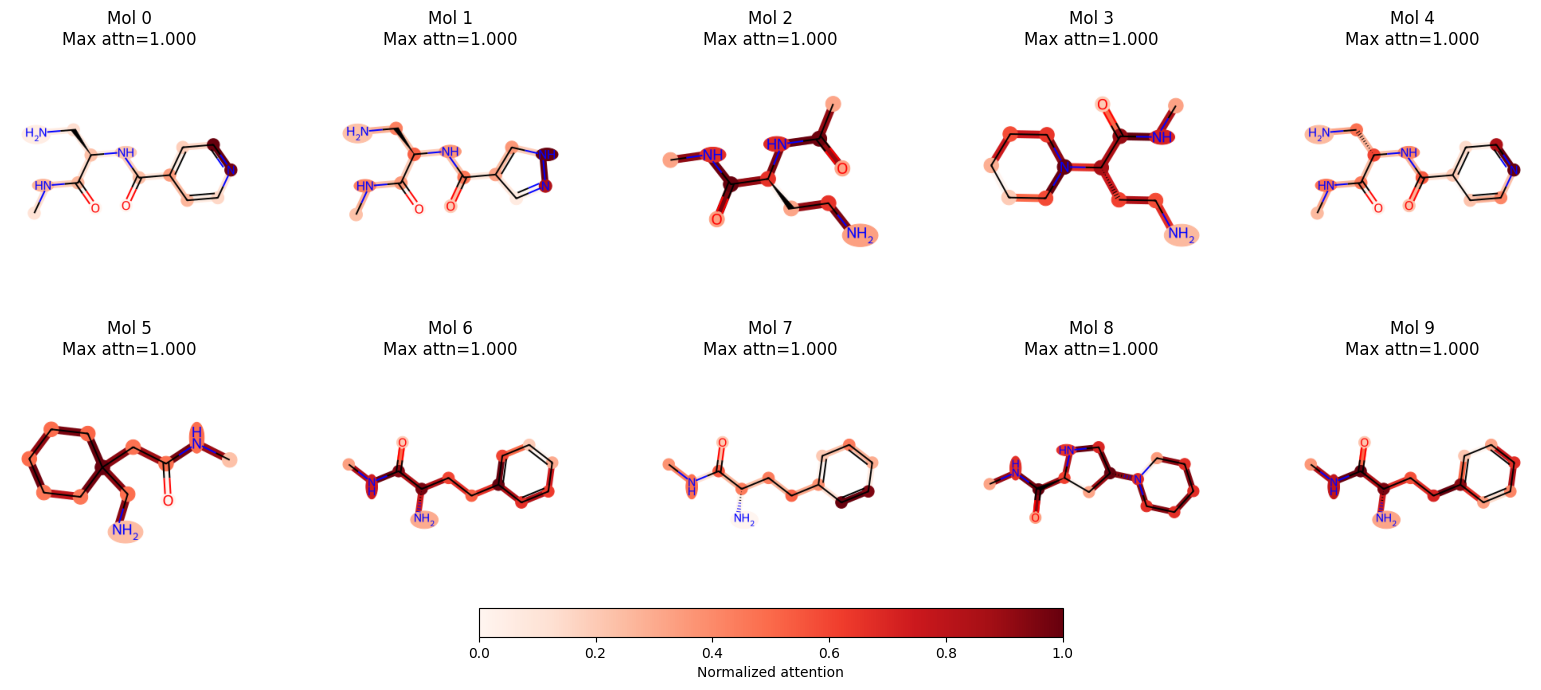

In [22]:
# Visualize top 5 molecules for synthon 0, last GAT layer
visualize_top_attention(flat_attention_list, dataset, syn_idx=0, top_n=10, layer_idx=-1)

The above is only a emall example as we're only training on 1000 molecules. But in principle, visualising the attention weights from the transformer has the following purpose:

- A GAT computes a representation for each node by attending to its neighbors.
- Attention weights (α) tell you how much the model "focuses" on each bond/neighbor when updating a node’s representation.

For each bond (i, j) in the molecule, the GAT computes a weight between 0 and 1 (after normalization).

- A **high attention weight** means the model considers that bond more important for predicting the property of interest (in this case, enrichment = activity).
- A **low weight** means the model thinks it’s less informative.

So in a weekly workflow:

* Run the screen → get sequencing counts.
* Feed data into the model.
* Generate predictions + attention maps.
* Prioritize hits + select chemistries for next round of DEL synthesis.

This could accelerate the cycle from weeks to days.

### Synthon pair enrichment.

In [114]:
import torch
from copy import deepcopy
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def mask_synthon(graph):
    """Return a copy of the synthon graph with all atom/bond features zeroed."""
    g = deepcopy(graph)
    g.x = torch.zeros_like(g.x)
    g.edge_attr = torch.zeros_like(g.edge_attr)
    return g

def predict(model, synthons):
    """Run model on a list of 3 synthon graphs."""
    model.eval()
    with torch.no_grad():
        synthons = [g.to(device) for g in synthons]
        pred = model(synthons)
    return pred.item()

def compute_pairwise_synergy(model, dataset, n_samples=500):
    """
    Compute synthon interaction synergy for random subset of dataset.
    Returns dict: synergy_AB, synergy_AC, synergy_BC.
    """
    synergy_AB = []
    synergy_AC = []
    synergy_BC = []

    indices = np.random.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)

    for idx in indices:
        d = dataset[idx]
        A, B, C = d["synthon_graphs"]

        # Original
        fABC = predict(model, [A, B, C])

        # Singles masked
        f0BC = predict(model, [mask_synthon(A), B, C])
        fA0C = predict(model, [A, mask_synthon(B), C])
        fAB0 = predict(model, [A, B, mask_synthon(C)])

        # Double masked (baseline interactions)
        f00C = predict(model, [mask_synthon(A), mask_synthon(B), C])
        f0B0 = predict(model, [mask_synthon(A), B, mask_synthon(C)])
        fA00 = predict(model, [A, mask_synthon(B), mask_synthon(C)])

        # Compute pairwise interactions
        AB = fABC - f0BC - fA0C + f00C
        AC = fABC - f0BC - fAB0 + f0B0
        BC = fABC - fA0C - fAB0 + fA00

        synergy_AB.append(AB)
        synergy_AC.append(AC)
        synergy_BC.append(BC)

    return {
        "AB": np.array(synergy_AB),
        "AC": np.array(synergy_AC),
        "BC": np.array(synergy_BC),
    }

# --- Run it ---
synergy = compute_pairwise_synergy(model, dataset)

print("Mean synergy (A–B):", synergy["AB"].mean())
print("Mean synergy (A–C):", synergy["AC"].mean())
print("Mean synergy (B–C]:", synergy["BC"].mean())


Mean synergy (A–B): 9.078830480575561e-07
Mean synergy (A–C): 2.8872489929199217e-06
Mean synergy (B–C]: 4.939883947372437e-07


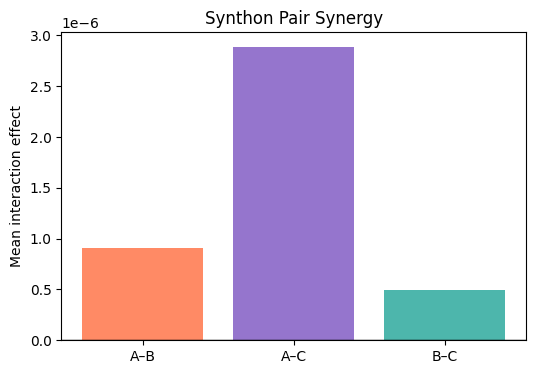

In [115]:
import matplotlib.pyplot as plt

pairs = ["A–B", "A–C", "B–C"]
values = [synergy["AB"].mean(), synergy["AC"].mean(), synergy["BC"].mean()]

plt.figure(figsize=(6,4))
plt.bar(pairs, values, color=["#ff8a65", "#9575cd", "#4db6ac"])
plt.axhline(0, color='black', linewidth=1)
plt.ylabel("Mean interaction effect")
plt.title("Synthon Pair Synergy")
plt.show()


In [116]:
import torch
from copy import deepcopy
import numpy as np
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.rdmolops import GetSymmSSSR
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.data import Batch, Data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Helper functions
# -----------------------------

def mask_synthon(graph):
    g = deepcopy(graph)
    g.x = torch.zeros_like(g.x)
    g.edge_attr = torch.zeros_like(g.edge_attr)
    return g

def predict(model, synthons):
    model.eval()
    with torch.no_grad():
        synthons = [g.to(device) for g in synthons]
        pred = model(synthons)
    return pred.item()

def atom_attention_from_alpha(mol_data, edge_idx, alpha):
    n_atoms = mol_data.x.size(0)
    atom_scores = torch.zeros(n_atoms)
    edges = edge_idx.t().tolist()
    alpha = alpha.detach().cpu()

    for (i, j), score in zip(edges, alpha):
        atom_scores[i] += score
        atom_scores[j] += score

    if atom_scores.max() > 0:
        atom_scores /= atom_scores.max()

    return atom_scores.numpy()

def get_fragments(mol):
    frags = []

    # Rings
    for ring in GetSymmSSSR(mol):
        atom_ids = list(ring)
        frags.append(("ring", tuple(atom_ids)))

    # Murcko core
    core = MurckoScaffold.GetScaffoldForMol(mol)
    if core:
        mapping = mol.GetSubstructMatch(core)
        if mapping:
            frags.append(("murcko", tuple(mapping)))

    # TODO: Add SMARTS fragments here if desired
    return frags

def empty_graph_like(data):
    return Data(
        x=torch.zeros((0, data.x.size(1))),
        edge_index=torch.zeros((2,0), dtype=torch.long),
        edge_attr=torch.zeros((0, data.edge_attr.size(1)))
    )

# -----------------------------
# Main report function
# -----------------------------

def synergy_fragment_report(model, dataset, n_samples=300):
    """
    Compute pairwise and triple synthon synergy,
    plus fragment attention enrichment per synthon.
    
    Returns:
        report: dict with keys:
            - 'synergy': dataframe of top AB/AC/BC/ABC synergy
            - 'fragment_attention': dataframe of fragment enrichment per synthon
    """
    model.eval()
    synergy_data = defaultdict(list)
    frag_att = {0:defaultdict(list), 1:defaultdict(list), 2:defaultdict(list)}
    
    indices = np.random.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)
    
    for idx in indices:
        d = dataset[idx]
        A, B, C = d["synthon_graphs"]
        
        # --- Predictions ---
        fABC = predict(model, [A, B, C])
        f0BC = predict(model, [mask_synthon(A), B, C])
        fA0C = predict(model, [A, mask_synthon(B), C])
        fAB0 = predict(model, [A, B, mask_synthon(C)])
        f00C = predict(model, [mask_synthon(A), mask_synthon(B), C])
        f0B0 = predict(model, [mask_synthon(A), B, mask_synthon(C)])
        fA00 = predict(model, [A, mask_synthon(B), mask_synthon(C)])
        
        # --- Synergy ---
        AB = fABC - f0BC - fA0C + f00C
        AC = fABC - f0BC - fAB0 + f0B0
        BC = fABC - fA0C - fAB0 + fA00
        ABC = fABC - f0BC - fA0C - fAB0 + f00C + f0B0 + fA00
        
        synergy_data['AB'].append(AB)
        synergy_data['AC'].append(AC)
        synergy_data['BC'].append(BC)
        synergy_data['ABC'].append(ABC)
        
        # --- Fragment attention ---
        for syn_idx in range(3):
            mol_data = d["synthon_graphs"][syn_idx]
            mol = Chem.MolFromSmiles(mol_data.smiles)
            
            # Build batch for model
            syn_batch = []
            for k in range(3):
                g = d["synthon_graphs"][k]
                syn_batch.append(Batch.from_data_list([g.to(device)]))
            
            _, attn = model(syn_batch, return_attention=True)
            mol_attn = attn[0][syn_idx][-1]  # last layer
            
            if isinstance(mol_attn, tuple):
                edge_idx, alpha = mol_attn
            else:
                # handle multi-head GAT
                edge_idx, alpha = mol_attn[0]
                if isinstance(alpha, list):
                    alpha = torch.stack(alpha, dim=0).mean(dim=0)
            
            atom_scores = atom_attention_from_alpha(mol_data, edge_idx, alpha)
            fragments = get_fragments(mol)
            
            for frag_type, atom_ids in fragments:
                frag_att[syn_idx][(frag_type, atom_ids)].append(np.mean(atom_scores[list(atom_ids)]))
    
    # --- Synergy table ---
    synergy_df = pd.DataFrame({k: np.array(v) for k,v in synergy_data.items()})
    
    # --- Fragment attention table ---
    frag_rows = []
    for syn_idx, frag_dict in frag_att.items():
        for (ftype, atom_ids), scores in frag_dict.items():
            frag_rows.append({
                "synthon": syn_idx,
                "fragment_type": ftype,
                "atom_ids": atom_ids,
                "mean_attention": np.mean(scores),
                "count": len(scores)
            })
    
    frag_df = pd.DataFrame(frag_rows).sort_values(["synthon","mean_attention"], ascending=[True, False])
    
    report = {
        "synergy": synergy_df,
        "fragment_attention": frag_df
    }
    
    return report

# -----------------------------
# Visualization helpers
# -----------------------------

def plot_synergy(df):
    plt.figure(figsize=(6,4))
    pairs = ['AB','AC','BC','ABC']
    values = [df[k].mean() for k in pairs]
    plt.bar(pairs, values, color=["#ff8a65", "#9575cd", "#4db6ac", "#ffa726"])
    plt.axhline(0, color='black', linewidth=1)
    plt.ylabel("Mean synergy / interaction effect")
    plt.title("Synthon Synergy")
    plt.show()

def top_fragments(df, syn_idx=0, top_n=10):
    return df[df.synthon==syn_idx].head(top_n)



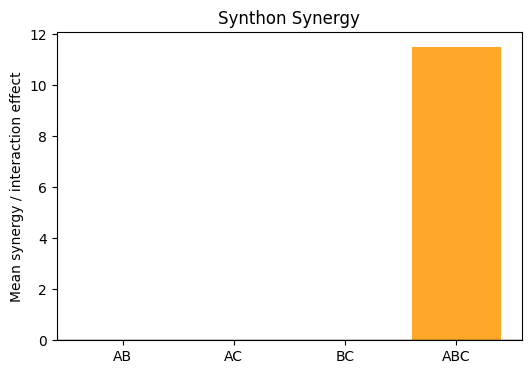

,synthon,fragment_type,atom_ids,mean_attention,count
360,2,ring,"(13, 11, 10, 15, 14)",0.841187,2
326,2,ring,"(26, 27, 28, 29, 30, 25)",0.821591,3
325,2,ring,"(20, 21, 22, 23, 24, 19)",0.821360,3
302,2,ring,"(25, 26, 27, 28, 29, 24)",0.820347,117
366,2,ring,"(3, 12, 11, 10, 5, 4)",0.816362,3
301,2,ring,"(19, 20, 21, 22, 23, 18)",0.815524,122
319,2,murcko,"(3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, ...",0.812149,27
350,2,murcko,"(3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, ...",0.812149,3
341,2,murcko,"(4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...",0.810344,9
318,2,ring,"(6, 7, 8, 9, 11, 5)",0.810148,27


In [117]:
# Compute report (this may take a few minutes)
report = synergy_fragment_report(model, dataset, n_samples=300)

# Top pairwise / triple synergy
report['synergy'].describe()

# Plot mean synergy
plot_synergy(report['synergy'])

# Top fragments for each synthon
top_fragments(report['fragment_attention'], syn_idx=0)
top_fragments(report['fragment_attention'], syn_idx=1)
top_fragments(report['fragment_attention'], syn_idx=2)


In [118]:
from rdkit.Chem import Draw
from matplotlib.cm import get_cmap
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem

# -----------------------------
# Fragment visualization
# -----------------------------
def visualize_top_fragments(dataset, frag_df, syn_idx=0, top_n=5, mol_size=(300,300)):
    """
    Show top fragments for a given synthon with highlighted atoms.
    """
    # Filter fragments for this synthon
    df = frag_df[frag_df.synthon==syn_idx].head(top_n)
    
    ncols = 2
    nrows = (len(df) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = axes.flatten()
    
    for i, (_, row) in enumerate(df.iterrows()):
        frag_atoms = set(row.atom_ids)
        mol = None
        
        # Find a molecule that contains the fragment
        for d in dataset:
            mol_data = d["synthon_graphs"][syn_idx]
            mol = Chem.MolFromSmiles(mol_data.smiles)
            if mol is None:
                continue
            if len(frag_atoms) == 0 or max(frag_atoms) < mol.GetNumAtoms():
                break
        
        if mol is None:
            continue
        
        # Highlight fragment atoms
        atom_colors = {idx:(1.0,0.5,0.5) for idx in frag_atoms}  # light red
        img = Draw.MolToImage(mol, size=mol_size,
                              highlightAtoms=list(atom_colors.keys()),
                              highlightAtomColors=atom_colors)
        
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"{row.fragment_type}\nMean attn={row.mean_attention:.2f}")
    
    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()

# -----------------------------
# Molecule highlighting with colormap
# -----------------------------
def visualize_fragments_on_mols(dataset, frag_df, syn_idx=0, top_n=5, cmap_name="Reds"):
    """
    Visualize the top-N fragments by mean attention for a given synthon index.
    Highlights the fragment atoms on the molecule using a colormap.
    """
    cmap = get_cmap(cmap_name)
    top_frags = frag_df[frag_df.synthon==syn_idx].head(top_n)
    
    ncols = min(top_n, 5)
    nrows = int(np.ceil(len(top_frags)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = axes.flatten() if nrows*ncols > 1 else [axes]
    
    for ax_idx, (_, row) in enumerate(top_frags.iterrows()):
        ax = axes[ax_idx]
        # Pick the first molecule from the dataset
        d = dataset[0]
        mol_data = d["synthon_graphs"][syn_idx]
        mol = Chem.MolFromSmiles(mol_data.smiles)
        if mol is None:
            continue
        
        # Clip fragment atom indices to molecule
        atom_ids = [i for i in row.atom_ids if i < mol.GetNumAtoms()]
        if len(atom_ids) == 0:
            continue  # skip if no valid atoms
        
        color_val = row.mean_attention
        atom_colors = {i: cmap(color_val)[:3] for i in atom_ids}
        
        # Draw molecule
        Draw.rdMolDraw2D.PrepareMolForDrawing(mol)
        drawer = Draw.MolDraw2DCairo(300,300)
        drawer.DrawMolecule(
            mol,
            highlightAtoms=atom_ids,
            highlightAtomColors=atom_colors
        )
        drawer.FinishDrawing()
        img_bytes = drawer.GetDrawingText()
        img = Image.open(BytesIO(img_bytes))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{row.fragment_type}\nAtoms {atom_ids}\nAttn={color_val:.2f}")
    
    # Hide unused axes
    for ax_idx in range(len(top_frags), len(axes)):
        axes[ax_idx].axis('off')
    
    plt.tight_layout()
    plt.show()


# -----------------------------
# Highlight fragments driving top synergy
# -----------------------------
def visualize_top_synergy_fragments(report, dataset, top_pairs=3, top_frags=3):
    """
    For the top synergistic synthon pairs (AB, AC, BC),
    show the fragments driving the synergy for each synthon.
    Handles missing fragments gracefully.
    """
    synergy_df = report['synergy']
    frag_df = report['fragment_attention']

    pairs = ['AB','AC','BC']
    for pair in pairs[:top_pairs]:
        mean_val = synergy_df[pair].mean()
        print(f"\nMean synergy {pair}: {mean_val:.3f}")

        # Determine synthon indices
        if pair=="AB":
            syn1, syn2 = 0,1
        elif pair=="AC":
            syn1, syn2 = 0,2
        elif pair=="BC":
            syn1, syn2 = 1,2
        else:
            continue

        # Plot fragments for each synthon if they exist
        for syn_idx, name in zip([syn1,syn2], pair.split('-')):
            top_frag = frag_df[frag_df.synthon==syn_idx]
            if top_frag.empty:
                print(f"No fragments found for synthon {syn_idx} ({name}) in this sample.")
                continue

            print(f"Top fragments for synthon {syn_idx} ({name}):")
            visualize_fragments_on_mols(
                dataset=dataset,
                frag_df=top_frag,
                syn_idx=syn_idx,
                top_n=top_frags
            )




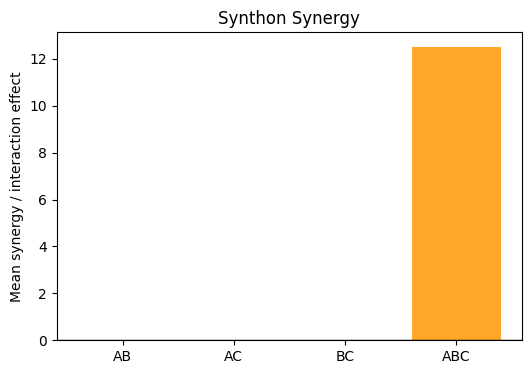


Mean synergy AB: 0.000
Top fragments for synthon 0 (AB):


/tmp/ipykernel_4738/1509496337.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


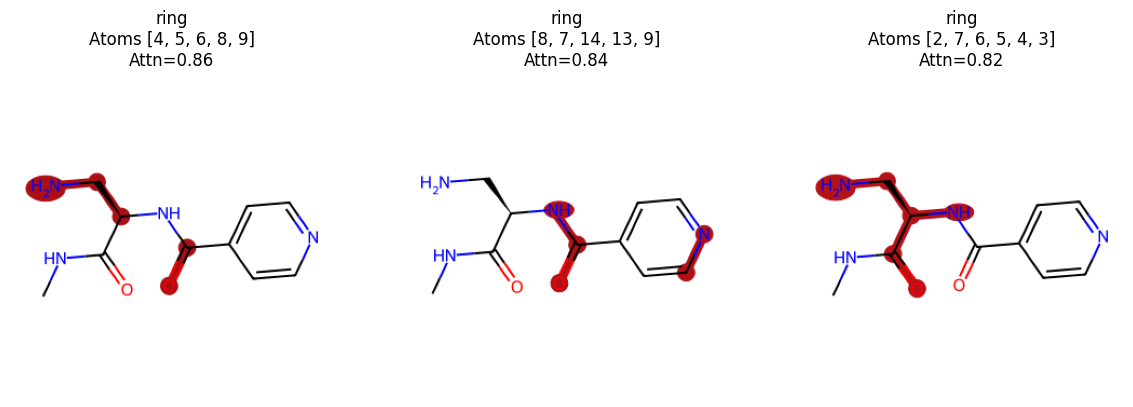


Mean synergy AC: 0.000
Top fragments for synthon 0 (AC):


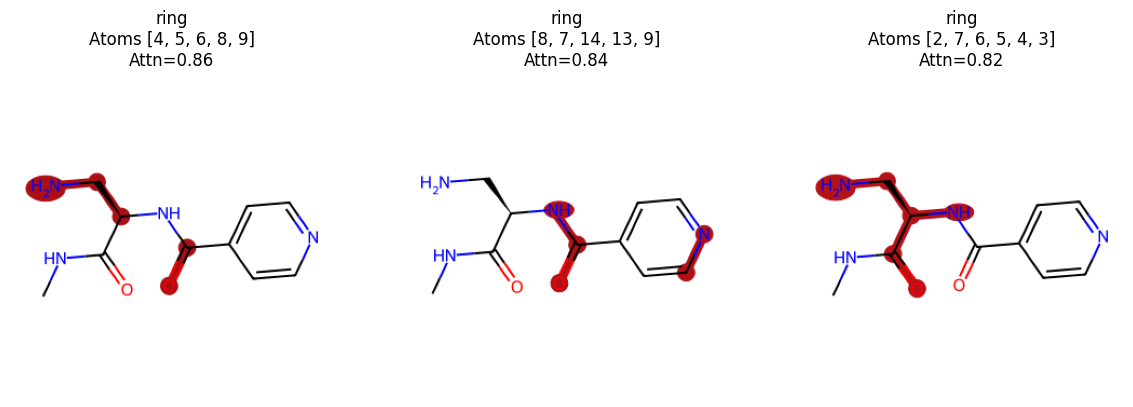


Mean synergy BC: 0.000
Top fragments for synthon 1 (BC):


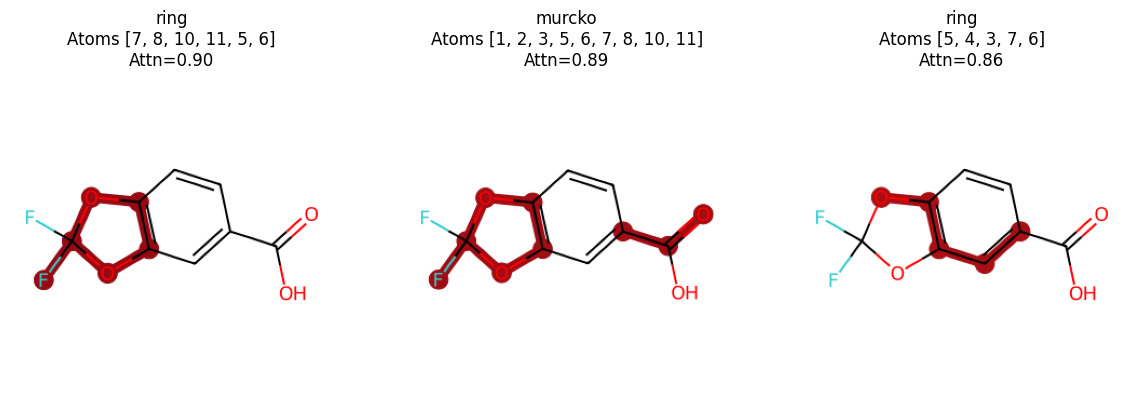

In [121]:
# -----------------------------
# Example usage
# -----------------------------
report = synergy_fragment_report(model, dataset, n_samples=300)

# Plot synergy summary
plot_synergy(report['synergy'])

# # Show top fragments per synthon
# for syn_idx in range(3):
#     print(f"--- Synthon {syn_idx} ---")
#     visualize_top_fragments(dataset, report['fragment_attention'], syn_idx=syn_idx, top_n=5)

# Highlight fragments driving top synergy
visualize_top_synergy_fragments(report, dataset, top_pairs=3, top_frags=3)


Quick analogy

Think of the synthons as three ingredients in a recipe:

Synergy = “taste boost” when two ingredients combine.

Fragment highlights = the “key flavor notes” in each ingredient responsible for the boost.

Together → you know both which ingredients matter together and which part of each ingredient is doing the work.